# MPAS-Ocean Support in Nereus

This notebook demonstrates loading and working with MPAS-Ocean output using nereus.

MPAS-Ocean uses an unstructured Voronoi mesh. Unlike MITgcm (binary MDS files), MPAS stores everything in standard NetCDF — mesh information is embedded directly in every output file.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import nereus as nr
import numpy as np

data_path = "/Users/nkolduno/PYTHON/DATA/MPAS/MPAS-O_V6.0_EC60to30/oEC60to30v3_60layer.170905.nc"

## Load mesh

In [3]:
mesh = nr.mpas.load_mesh(data_path)
mesh

<xarray.Dataset> Size: 8MB
Dimensions:          (npoints: 235160, depth_level: 60)
Dimensions without coordinates: npoints, depth_level
Data variables:
    lon              (npoints) float64 2MB -174.7 129.0 120.1 ... -97.86 144.0
    lat              (npoints) float64 2MB 62.2 18.47 -18.47 ... -68.17 11.8
    area             (npoints) float64 2MB 2.414e+09 1.401e+09 ... 8.996e+08
    depth            (depth_level) float64 480B 5.0 15.0 ... 5.125e+03 5.375e+03
    layer_thickness  (depth_level) float64 480B 10.0 10.0 10.0 ... 250.0 250.0
    bathymetry       (npoints) float64 2MB 82.47 5.477e+03 ... 4.525e+03 5.5e+03
    maxLevelCell     (npoints) int32 941kB 9 60 11 59 57 3 ... 53 58 52 56 57 60
Attributes:
    nereus_mesh_type:     mpas
    nereus_mesh_version:  1.0
    nereus_dask_backend:  False
    nereus_source_path:   /Users/nkolduno/PYTHON/DATA/MPAS/MPAS-O_V6.0_EC60to...

In [4]:
# Auto-detection also works
mesh_auto = nr.load_mesh(data_path)
mesh_auto.attrs["nereus_mesh_type"]

'mpas'

In [5]:
# Mesh info
print(f"Number of cells: {mesh.sizes['npoints']}")
print(f"Lon range: {float(mesh.lon.min()):.2f} to {float(mesh.lon.max()):.2f}")
print(f"Lat range: {float(mesh.lat.min()):.2f} to {float(mesh.lat.max()):.2f}")
print(f"Area range: {float(mesh.area.min()):.2e} to {float(mesh.area.max()):.2e} m^2")
print(f"Depth levels: {mesh.sizes['depth_level']}")
print(f"Depth range: {float(mesh.depth.min()):.1f} to {float(mesh.depth.max()):.1f} m")
print(f"Bathymetry range: {float(mesh.bathymetry.min()):.1f} to {float(mesh.bathymetry.max()):.1f} m")

Number of cells: 235160
Lon range: -180.00 to 180.00
Lat range: -78.52 to 89.92
Area range: 5.17e+08 to 4.31e+09 m^2
Depth levels: 60
Depth range: 5.0 to 5375.0 m
Bathymetry range: 30.0 to 5500.0 m


## Open data

MPAS data is standard NetCDF, so `open_dataset` simply attaches mesh coordinates.
Since MPAS embeds mesh info in every file, you can even skip providing a mesh — it will be loaded from the data file itself.

In [6]:
ds = nr.mpas.open_dataset(data_path, mesh=mesh)
ds

<xarray.Dataset> Size: 1GB
Dimensions:                        (Time: 1, nCells: 235160, nEdges: 714274,
                                    nVertices: 478835, maxEdges: 7, TWO: 2,
                                    vertexDegree: 3, maxEdges2: 14,
                                    nVertLevels: 60, nVertLevelsP1: 61)
Coordinates:
    lon                            (nCells) float64 2MB -174.7 129.0 ... 144.0
    lat                            (nCells) float64 2MB 62.2 18.47 ... 11.8
    depth                          (nVertLevels) float64 480B 5.0 ... 5.375e+03
Dimensions without coordinates: Time, nCells, nEdges, nVertices, maxEdges, TWO,
                                vertexDegree, maxEdges2, nVertLevels,
                                nVertLevelsP1
Data variables: (12/62)
    SSHGradientMeridional          (Time, nCells) float64 2MB ...
    SSHGradientZonal               (Time, nCells) float64 2MB ...
    angleEdge                      (nEdges) float64 6MB ...
    areaCell                       (nCells) float64 2MB ...
    areaTriangle                   (nVertices) float64 4MB ...
    atmosphericPressure            (Time, nCells) float64 2MB ...
    ...                             ...
    yCell                          (nCells) float64 2MB ...
    yEdge                          (nEdges) float64 6MB ...
    yVertex                        (nVertices) float64 4MB ...
    zCell                          (nCells) float64 2MB ...
    zEdge                          (nEdges) float64 6MB ...
    zVertex                        (nVertices) float64 4MB ...
Attributes: (12/944)
    model_name:                                                      mpas
    core_name:                                                       ocean
    source:                                                          MPAS
    Conventions:                                                     MPAS
    git_version:                                                     v5.0-127...
    on_a_sphere:                                                     YES
    ...                                                              ...
    config_AM_mocStreamfunction_vertical_velocity_value:             vertVelo...
    config_AM_mocStreamfunction_normal_velocity_value:               normalVe...
    config_AM_mocStreamfunction_region_group:                        all
    config_AM_mocStreamfunction_transect_group:                      all
    file_id:                                                         a3seglhl6y
    NCO:                                                             4.6.7

In [7]:
# List all time-dependent data variables
print("2D variables (Time, nCells):")
for name in ds.data_vars:
    if ds[name].dims == ("Time", "nCells"):
        print(f"  {name}")
print("\n3D variables (Time, nCells, nVertLevels):")
for name in ds.data_vars:
    if ds[name].dims == ("Time", "nCells", "nVertLevels"):
        print(f"  {name}")

2D variables (Time, nCells):
  SSHGradientMeridional
  SSHGradientZonal
  atmosphericPressure
  boundaryLayerDepth
  filteredSSHGradientMeridional
  filteredSSHGradientZonal
  salinitySurfaceValue
  seaIcePressure
  surfaceVelocityMeridional
  surfaceVelocityZonal
  temperatureSurfaceValue

3D variables (Time, nCells, nVertLevels):
  layerThickness
  salinity
  temperature


## Plotting

Text(0.5, 1.0, 'Sea Surface Temperature (MPAS-Ocean)')

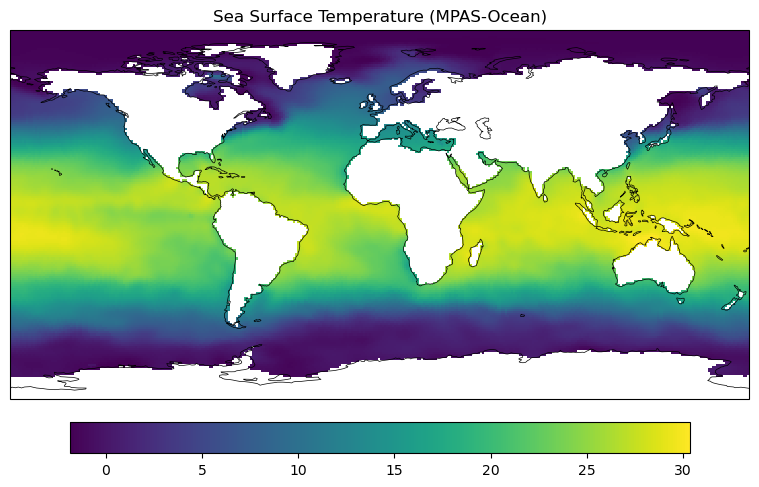

In [8]:
# Plot SST (surface temperature)
sst = ds["temperature"].isel(Time=0, nVertLevels=0).values
fig, ax, interp = nr.plot(sst, mesh["lon"].values, mesh["lat"].values)
ax.set_title("Sea Surface Temperature (MPAS-Ocean)")

Text(0.5, 1.0, 'Sea Surface Salinity (MPAS-Ocean)')

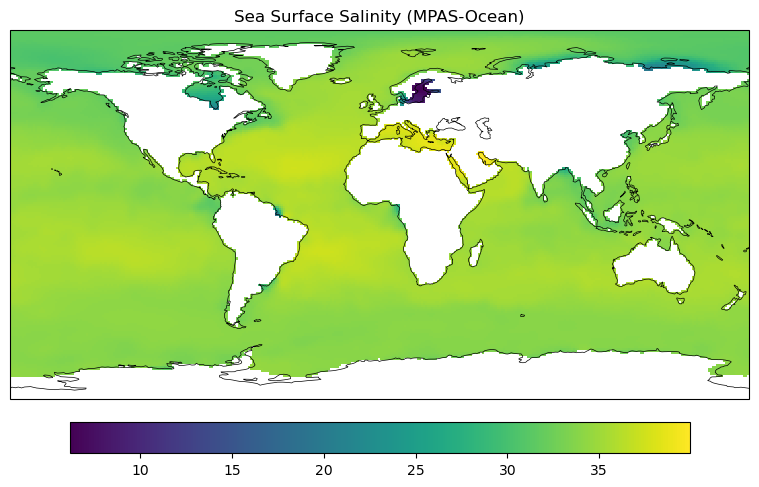

In [9]:
# Plot surface salinity
sss = ds["salinity"].isel(Time=0, nVertLevels=0).values
fig, ax, _ = nr.plot(sss, mesh["lon"].values, mesh["lat"].values)
ax.set_title("Sea Surface Salinity (MPAS-Ocean)")

Text(0.5, 1.0, 'Bathymetry (m)')

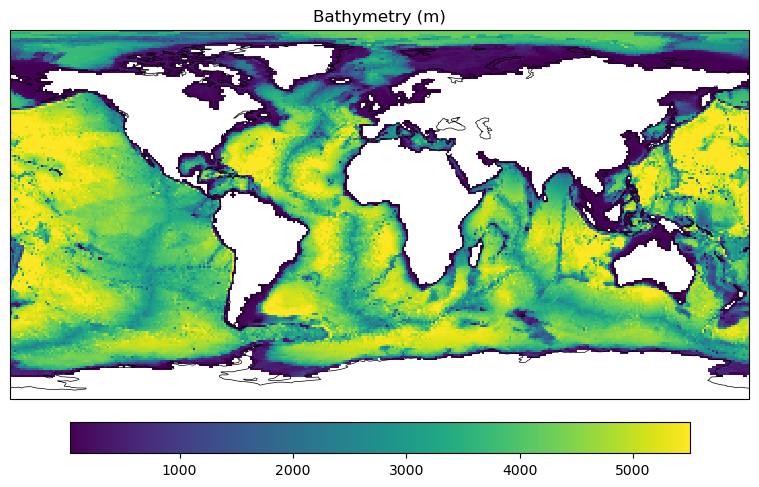

In [10]:
# Plot bathymetry
fig, ax, _ = nr.plot(mesh["bathymetry"].values,
    mesh["lon"].values, mesh["lat"].values)
ax.set_title("Bathymetry (m)")

## Diagnostics

In [11]:
# Surface mean SST
mean_sst = nr.surface_mean(sst, mesh["area"].values)
print(f"Global mean SST: {mean_sst:.2f} \u00b0C")

Global mean SST: 18.16 °C


In [12]:
# Depth levels and layer thickness
print("Depth levels (m):", mesh["depth"].values)
print("Layer thickness (m):", mesh["layer_thickness"].values)

Depth levels (m): [5.00000000e+00 1.50000000e+01 2.50000000e+01 3.50000000e+01
 4.50000000e+01 5.50000000e+01 6.50000000e+01 7.50000000e+01
 8.50000000e+01 9.50000000e+01 1.05000000e+02 1.15000000e+02
 1.25000000e+02 1.35000000e+02 1.45000000e+02 1.55000000e+02
 1.65098398e+02 1.75479043e+02 1.86291250e+02 1.97660254e+02
 2.09711348e+02 2.22578262e+02 2.36408809e+02 2.51370137e+02
 2.67654160e+02 2.85483613e+02 3.05119180e+02 3.26867949e+02
 3.51093437e+02 3.78227539e+02 4.08784609e+02 4.43377656e+02
 4.82736680e+02 5.27727969e+02 5.79372852e+02 6.38862578e+02
 7.07563281e+02 7.87002500e+02 8.78825234e+02 9.84705859e+02
 1.10620422e+03 1.24456695e+03 1.40049719e+03 1.57394641e+03
 1.76400328e+03 1.96894422e+03 2.18645656e+03 2.41397156e+03
 2.64900125e+03 2.88938469e+03 3.13340469e+03 3.37979375e+03
 3.62767063e+03 3.87645219e+03 4.12576844e+03 4.37539281e+03
 4.62519063e+03 4.87508375e+03 5.12502844e+03 5.37500000e+03]
Layer thickness (m): [ 10.          10.          10.          10. 

Closest depth to 100m: 95.0m (index 9)


Text(0.5, 1.0, 'Temperature at 95m depth')

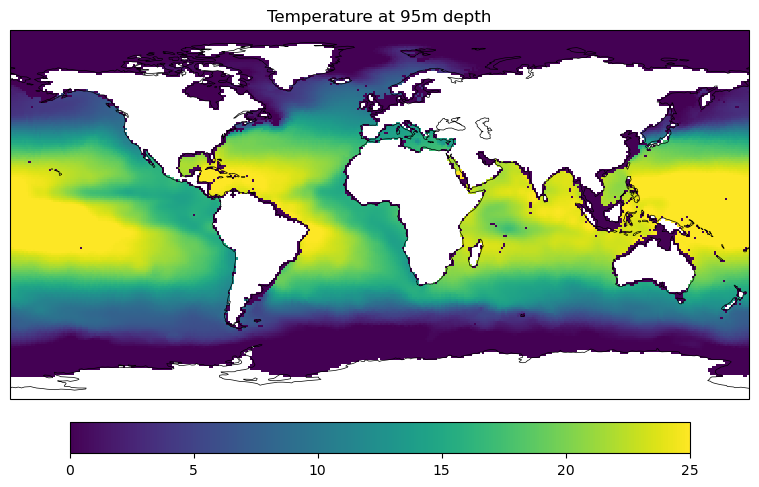

In [18]:
# Temperature at a specific depth (~100m)
idx, depth_val = nr.find_closest_depth(mesh["depth"].values, 100)
print(f"Closest depth to 100m: {depth_val:.1f}m (index {idx})")
temp_100m = ds["temperature"].isel(Time=0, nVertLevels=idx).values
fig, ax, _ = nr.plot(temp_100m, mesh["lon"].values, mesh["lat"].values, vmin=0, vmax=25)
ax.set_title(f"Temperature at {depth_val:.0f}m depth")

## Projections and regridding

Text(0.5, 1.0, 'Arctic SST (MPAS-Ocean)')

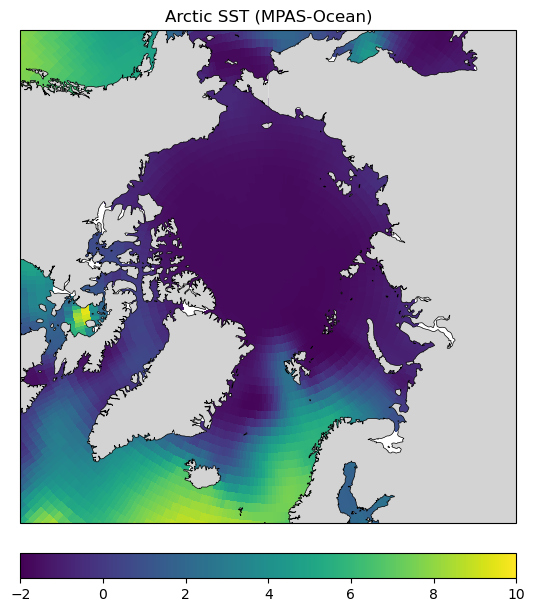

In [21]:
# Arctic view
fig, ax, _ = nr.plot(sst, mesh["lon"].values, mesh["lat"].values,
    projection="npstere", extent=[-180, 180, 60, 90], land=True, vmin=-2, vmax=10)
ax.set_title("Arctic SST (MPAS-Ocean)")

Text(0.5, 1.0, 'Antarctic SST (MPAS-Ocean)')

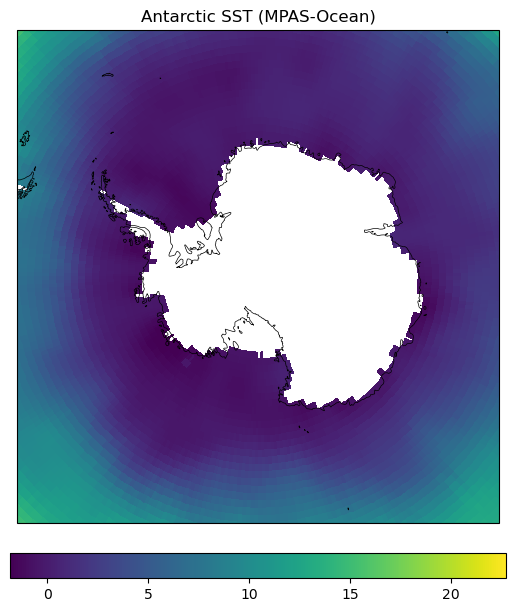

In [22]:
# Antarctic view
fig, ax, _ = nr.plot(sst, mesh["lon"].values, mesh["lat"].values,
    projection="spstere", extent=[-180, 180, -90, -55])
ax.set_title("Antarctic SST (MPAS-Ocean)")

In [23]:
# Regrid to regular grid
regridded, interp = nr.regrid(sst, mesh["lon"].values, mesh["lat"].values,
    resolution=0.5)
print(f"Regridded shape: {regridded.shape}")

Regridded shape: (360, 720)


In [24]:
# Spatial queries
# Find nearest point to a specific location (e.g., North Atlantic)
idx_na = nr.find_nearest(mesh["lon"].values, mesh["lat"].values, -30.0, 50.0)
print(f"Nearest point to (-30, 50): index {idx_na}")
print(f"  lon={mesh['lon'].values[idx_na]:.2f}, lat={mesh['lat'].values[idx_na]:.2f}")
print(f"  SST={sst[idx_na]:.2f} \u00b0C")
print(f"  Depth={mesh['bathymetry'].values[idx_na]:.0f} m")

Nearest point to (-30, 50): index 58894
  lon=-29.90, lat=50.16
  SST=10.89 °C
  Depth=3035 m
